# 🧠 Model Explainability using SHAP

This notebook explains how the trained model makes predictions.

We will use:
- Feature Importance
- SHAP Summary Plot
- SHAP Dependence Plot

In [3]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings("ignore")

In [4]:
df = pd.read_csv("../data/processed/train_featured.csv")

X = df.drop("trip_duration", axis=1)
y = df["trip_duration"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [5]:
best_model = joblib.load("../models/best_model.pkl")

In [6]:
if hasattr(best_model, "feature_importances_"):
    feature_importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": best_model.feature_importances_
    }).sort_values(by="Importance", ascending=False)

    feature_importance
else:
    print("Feature importance is not available for this model.")

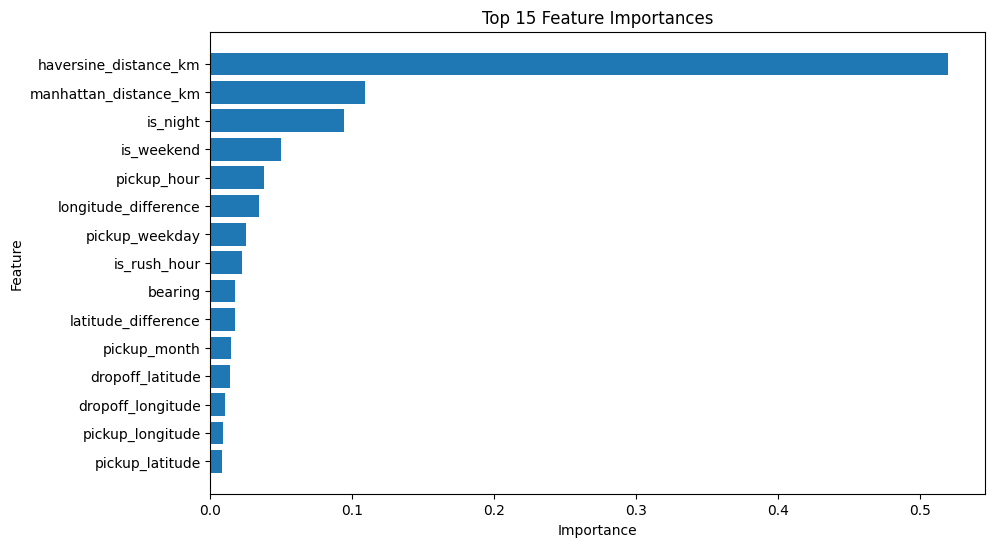

In [7]:
if hasattr(best_model, "feature_importances_"):
    plt.figure(figsize=(10,6))

    plt.barh(
        feature_importance["Feature"].head(15)[::-1],
        feature_importance["Importance"].head(15)[::-1]
    )

    plt.title("Top 15 Feature Importances")
    plt.xlabel("Importance")
    plt.ylabel("Feature")

    plt.show()

## SHAP Analysis

SHAP explains how each feature contributes to model predictions.

Positive SHAP values increase the predicted trip duration, while negative SHAP values decrease it.

In [15]:
X_sample = X_test.sample(1000, random_state=42)

In [ ]:
explainer = shap.Explainer(best_model, X_sample)

shap_values = explainer(X_sample)

Background dataset has 1000 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=1000 when initializing the masker.
 91%|==================  | 913/1000 [01:29<00:08]       

In [ ]:
shap.summary_plot(shap_values, X_sample)

In [ ]:
shap.summary_plot(shap_values, X_sample, plot_type="bar")

In [ ]:
top_feature = feature_importance.iloc[0]["Feature"]

shap.dependence_plot(
    top_feature,
    shap_values.values,
    X_sample
)

In [ ]:
single_instance = X_sample.iloc[[0]]

single_prediction = best_model.predict(single_instance)

print("Predicted Trip Duration:", round(single_prediction[0], 2), "seconds")

In [ ]:
shap.plots.waterfall(shap_values[0])

# Conclusion

Model explainability is complete.

Key outputs:
- Feature importance shows which variables contribute most.
- SHAP summary plot explains global model behavior.
- SHAP waterfall plot explains individual predictions.

Next step: Error Analysis.

In [ ]:
shap.plots.beeswarm(shap_values)